In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
#data kotor
df = pd.read_csv('animal_disease_dataset.csv')
df.head()

,Animal,Age,Temperature,Symptom 1,Symptom 2,Symptom 3,Disease
0,cow,3,103.1,depression,painless lumps,loss of appetite,pneumonia
1,buffalo,13,104.5,painless lumps,loss of appetite,depression,lumpy virus
2,sheep,1,100.5,depression,painless lumps,loss of appetite,lumpy virus
3,cow,14,100.3,loss of appetite,swelling in limb,crackling sound,blackleg
4,sheep,2,103.6,painless lumps,loss of appetite,depression,pneumonia


In [5]:
#Pre-processing
df_cow = df[(df['Animal'] == 'cow') ]
df_cow.head()

,Animal,Age,Temperature,Symptom 1,Symptom 2,Symptom 3,Disease
0,cow,3,103.1,depression,painless lumps,loss of appetite,pneumonia
3,cow,14,100.3,loss of appetite,swelling in limb,crackling sound,blackleg
11,cow,11,103.9,depression,painless lumps,loss of appetite,lumpy virus
19,cow,14,102.7,shortness of breath,sweats,chills,anthrax
20,cow,1,103.7,depression,loss of appetite,painless lumps,lumpy virus


In [6]:
#Label Encoding
df_cow['target'] = df_cow['Disease'].apply(lambda x: 1 if str(x).lower() == 'foot and mouth' else 0)

/tmp/ipykernel_1641/2528997710.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cow['target'] = df_cow['Disease'].apply(lambda x: 1 if str(x).lower() == 'foot and mouth' else 0)


In [7]:
symptoms_encoded = pd.get_dummies(df_cow[['Symptom 1', 'Symptom 2', 'Symptom 3']], prefix='', prefix_sep='')
symptoms_encoded = symptoms_encoded.groupby(level=0, axis=1).max() # Menggabungkan kolom gejala yang namanya sama

/tmp/ipykernel_1641/1832114011.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  symptoms_encoded = symptoms_encoded.groupby(level=0, axis=1).max() # Menggabungkan kolom gejala yang namanya sama


In [8]:
scaler = StandardScaler()
df_cow[['Age', 'Temperature']] = scaler.fit_transform(df_cow[['Age', 'Temperature']])

/tmp/ipykernel_1641/2513746148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cow[['Age', 'Temperature']] = scaler.fit_transform(df_cow[['Age', 'Temperature']])


In [9]:
fitur_numerik = df_cow[['Age', 'Temperature']].reset_index(drop=True)
fitur_gejala = symptoms_encoded.reset_index(drop=True)
label_target = df_cow['target'].reset_index(drop=True)

df_final = pd.concat([fitur_numerik, fitur_gejala, label_target], axis=1)

df_final.to_csv('cow_fmd_preprocessed.csv', index=False)


print(f"Jumlah baris & kolom data sapi siap pakai: {df_final.shape}")
print(f"Jumlah Kasus FMD (1): {df_final['target'].value_counts()[1]}")
print(f"Jumlah Kasus Non-FMD (0): {df_final['target'].value_counts()[0]}")
print("\nContoh 5 data teratas:")
print(df_final.head())

Jumlah baris & kolom data sapi siap pakai: (11254, 27)
Jumlah Kasus FMD (1): 2433
Jumlah Kasus Non-FMD (0): 8821

Contoh 5 data teratas:
        Age  Temperature  blisters on gums  blisters on hooves  \
0 -1.160943     0.591769             False               False   
1  1.389098    -1.407882             False               False   
2  0.693632     1.163097             False               False   
3  1.389098     0.306104             False               False   
4 -1.624587     1.020265             False               False   

   blisters on mouth  blisters on tongue  chest discomfort  chills  \
0              False               False             False   False   
1              False               False             False   False   
2              False               False             False   False   
3              False               False             False    True   
4              False               False             False   False   

   crackling sound  depression  ...  sores on

In [10]:
from sklearn.model_selection import train_test_split
X = df_final.drop('target', axis=1)
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Menentukan jumlah input fitur dari dataframe yang sudah dibersihkan
# (Ganti X_train dengan variabel fitur kalian nantinya)
input_dim = X_train.shape[1]

model_mlp = Sequential([
    # Hidden Layer 1
    Dense(32, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2), # Mencegah overfitting

    # Hidden Layer 2
    Dense(16, activation='relu'),
    Dropout(0.2),

    # Output Layer (Binary Classification)
    Dense(1, activation='sigmoid')
])

# Kompilasi Model
model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Loss function standar untuk kelas biner (0/1)
    metrics=['accuracy']
)

model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 3.5561e-04 - val_accuracy: 1.0000 - val_loss: 1.1790e-06
Epoch 2/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 2.3457e-04 - val_accuracy: 1.0000 - val_loss: 6.2597e-07
Epoch 3/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 1.2664e-04 - val_accuracy: 1.0000 - val_loss: 2.7201e-07
Epoch 4/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 2.0551e-04 - val_accuracy: 1.0000 - val_loss: 1.2761e-07
Epoch 5/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 6.3576e-05 - val_accuracy: 1.0000 - val_loss: 7.8389e-08
Epoch 6/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 1.0000 - loss: 1.0524e-04 - val_accuracy: 1.0000 - val_loss: 6.0037e-08
Epoch 7/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 9.8618e-05 - val_accuracy: 1.0000 - val_loss: 2.1606e-08
Epoch 8/200
563/563 ━━━━━━━━━━━━━━━━━━━━ 

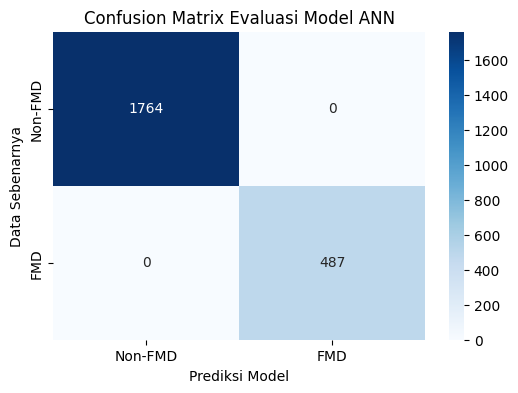

In [13]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True, verbose=1)

history = model_mlp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


loss, accuracy = model_mlp.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Keseluruhan (Testing): {accuracy*100:.2f}%\n")


y_pred_prob = model_mlp.predict(X_test)
y_pred_label = (y_pred_prob > 0.5).astype(int)


print("Classification Report:")
print(classification_report(y_test, y_pred_label, target_names=['Non-FMD (0)', 'FMD (1)']))

#visualisasi data
cm = confusion_matrix(y_test, y_pred_label)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-FMD', 'FMD'], yticklabels=['Non-FMD', 'FMD'])
plt.xlabel('Prediksi Model')
plt.ylabel('Data Sebenarnya')
plt.title('Confusion Matrix Evaluasi Model ANN')
plt.show()

In [16]:
import joblib
import pickle

model_mlp.save('model_pmk_ann.h5')

joblib.dump(scaler, 'scaler_pmk.pkl')


kolom_training = list(X_train.columns)
with open('kolom_fitur_pmk.pkl', 'wb') as f:
    pickle.dump(kolom_training, f)
